# CASO CANCER  

Claudia Lozano Pérez, 3º de Ingeniería matemática

In [1]:
#Librerías para análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
ruta_datos = Path("C:\\Users\\Usuario\\Desktop\\TERCERO\\2CUATRIMESTRE\\CANCER\\Base de datos")

bioquimicos = pd.read_csv(ruta_datos / "CASOCANCER_01_BIOQUIMICOS.csv")
clinicos = pd.read_csv(ruta_datos / "CASOCANCER_02_CLINICOS.csv")
geneticos = pd.read_csv(ruta_datos / "CASOCANCER_03_GENETICOS.csv")
economicos = pd.read_csv(ruta_datos / "CASOCANCER_04_ECONOMICOS.csv")
generales = pd.read_csv(ruta_datos / "CASOCANCER_05_GENERALES.csv")
sociodemograficos = pd.read_csv(ruta_datos / "CASOCANCER_06_SOCIODEMOGRAFICOS.csv")

In [3]:
datasets = {
    "bioquimicos": bioquimicos,
    "clinicos": clinicos,
    "geneticos": geneticos,
    "economicos": economicos,
    "generales": generales,
    "sociodemograficos": sociodemograficos
}

for nombre, datos in datasets.items():
    print(nombre, datos.shape)

bioquimicos (50001, 8)
clinicos (50001, 8)
geneticos (50001, 8)
economicos (50001, 6)
generales (50001, 5)
sociodemograficos (50001, 8)


## COMPROBACIÓN INICIAL DE LOS DATASETS

In [4]:

datasets = {
    "bioquimicos": bioquimicos,
    "clinicos": clinicos,
    "geneticos": geneticos,
    "economicos": economicos,
    "generales": generales,
    "sociodemograficos": sociodemograficos
}

for nombre, datos in datasets.items():
    print(f"{nombre}: {datos.shape}")
    print(datos.columns.tolist())
    print("-" * 80)

bioquimicos: (50001, 8)
['paciente_id', 'glucosa', 'colesterol', 'trigliceridos', 'hemoglobina', 'leucocitos', 'plaquetas', 'creatinina']
--------------------------------------------------------------------------------
clinicos: (50001, 8)
['paciente_id', 'diabetes', 'hipertension', 'obesidad', 'cancer', 'enfermedad_cardiaca', 'asma', 'epoc']
--------------------------------------------------------------------------------
geneticos: (50001, 8)
['paciente_id', 'mut_BRCA1', 'mut_TP53', 'mut_EGFR', 'mut_KRAS', 'mut_PIK3CA', 'mut_ALK', 'mut_BRAF']
--------------------------------------------------------------------------------
economicos: (50001, 6)
['paciente_id', 'tipo_seguro', 'coste_total', 'coste_farmaco', 'num_ingresos', 'dias_hospital']
--------------------------------------------------------------------------------
generales: (50001, 5)
['paciente_id', 'fumador', 'alcohol', 'actividad_fisica', 'vive']
--------------------------------------------------------------------------------


In [5]:
# Comprobar duplicados en la clave paciente_id

for nombre, datos in datasets.items():
    duplicados = datos["paciente_id"].duplicated().sum()
    print(f"{nombre}: {duplicados} paciente_id duplicados")

bioquimicos: 0 paciente_id duplicados
clinicos: 0 paciente_id duplicados
geneticos: 0 paciente_id duplicados
economicos: 0 paciente_id duplicados
generales: 0 paciente_id duplicados
sociodemograficos: 0 paciente_id duplicados


##  UNIR LAS COLECCIONES POR PACIENTE_ID

In [6]:

df = (
    clinicos
    .merge(bioquimicos, on="paciente_id", how="inner")
    .merge(geneticos, on="paciente_id", how="inner")
    .merge(economicos, on="paciente_id", how="inner")
    .merge(generales, on="paciente_id", how="inner")
    .merge(sociodemograficos, on="paciente_id", how="inner")
)

print("Dimensiones del dataset unido:", df.shape)

Dimensiones del dataset unido: (50001, 38)


In [7]:
df.head()

,paciente_id,diabetes,hipertension,obesidad,cancer,enfermedad_cardiaca,asma,epoc,glucosa,colesterol,...,alcohol,actividad_fisica,vive,edad,nivel_educativo,nivel_ingresos,zona,estado_civil,num_hijos,distancia_hospital_km
0,P1000000,0,0,1,0,0,0,0,94.66,205.32,...,1,Moderada,1,53,Secundaria,Medio,Urbana,Casado,2,25.6
1,P1000001,0,0,1,0,0,0,0,103.94,235.17,...,1,Moderada,1,66,Secundaria,Alto,Urbana,Divorciado,0,15.2
2,P1000002,1,1,0,1,0,1,0,131.34,138.42,...,1,Moderada,1,33,Secundaria,Bajo,Urbana,Casado,3,43.7
3,P1000003,1,1,0,0,0,0,0,115.03,182.81,...,1,Baja,1,45,Secundaria,Bajo,Urbana,Viudo,3,0.5
4,P1000004,0,0,1,0,0,0,0,103.97,237.70,...,1,Baja,1,53,Secundaria,Bajo,Urbana,Casado,0,7.3


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50001 entries, 0 to 50000
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   paciente_id            50001 non-null  object 
 1   diabetes               50001 non-null  int64  
 2   hipertension           50001 non-null  int64  
 3   obesidad               50001 non-null  int64  
 4   cancer                 50001 non-null  int64  
 5   enfermedad_cardiaca    50001 non-null  int64  
 6   asma                   50001 non-null  int64  
 7   epoc                   50001 non-null  int64  
 8   glucosa                50001 non-null  float64
 9   colesterol             50001 non-null  float64
 10  trigliceridos          50001 non-null  float64
 11  hemoglobina            50001 non-null  float64
 12  leucocitos             50001 non-null  float64
 13  plaquetas              50001 non-null  float64
 14  creatinina             50001 non-null  float64
 15  mu

In [9]:
print("Número de pacientes:", df.shape[0])
print("Número de variables:", df.shape[1])
print("Duplicados por paciente_id:", df["paciente_id"].duplicated().sum())
print("Valores nulos totales:", df.isnull().sum().sum())

Número de pacientes: 50001
Número de variables: 38
Duplicados por paciente_id: 0
Valores nulos totales: 0


## VARIABLE OBJETIVO Y DESBALANCE

In [10]:
# Distribución de la variable objetivo
df["cancer"].value_counts()

cancer
0    40357
1     9644
Name: count, dtype: int64

In [11]:
# Prevalencia de cáncer
prevalencia = df["cancer"].mean()
print(f"Prevalencia de cáncer: {prevalencia:.2%}")

Prevalencia de cáncer: 19.29%


In [12]:
# Razón de desbalance

conteo_clases = df["cancer"].value_counts()

n_no_cancer = conteo_clases[0]
n_cancer = conteo_clases[1]

razon_desbalance = n_no_cancer / n_cancer

print(f"Pacientes sin cáncer: {n_no_cancer}")
print(f"Pacientes con cáncer: {n_cancer}")
print(f"Razón de desbalance: {razon_desbalance:.2f} pacientes sin cáncer por cada paciente con cáncer")

Pacientes sin cáncer: 40357
Pacientes con cáncer: 9644
Razón de desbalance: 4.18 pacientes sin cáncer por cada paciente con cáncer


# FEATURE ENGINEERING

In [13]:

# Selección de variables

# Variables que NO deben entrar como predictoras
# porque son identificadores, la variable objetivo, constantes
# o consecuencias del diagnóstico.

variables_excluir = [
    "paciente_id",       # Identificador, no aporta valor predictivo
    "cancer",            # Variable objetivo
    "vive",              # Leakage: supervivencia posterior al diagnóstico
    "alcohol",           # Variable constante, no informativa
    "coste_total",       # Leakage: coste posterior/asociado al diagnóstico
    "coste_farmaco",     # Leakage
    "num_ingresos",      # Leakage
    "dias_hospital"      # Leakage
]

In [14]:
# Comorbilidades clínicas.
# En este primer modelo se excluyen para evitar posible leakage indirecto,
# ya que están correlacionadas con cancer por diseño del dataset.

comorbilidades_valorar = [
    #"diabetes",
    "hipertension",
    "obesidad",
    #"enfermedad_cardiaca",
    "asma",
    "epoc"
]

In [15]:
variables_excluir_modelo = variables_excluir + comorbilidades_valorar

X = df.drop(columns=variables_excluir_modelo)
y = df["cancer"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (50001, 26)
Dimensiones de y: (50001,)


In [16]:
X.columns.tolist()

['diabetes',
 'enfermedad_cardiaca',
 'glucosa',
 'colesterol',
 'trigliceridos',
 'hemoglobina',
 'leucocitos',
 'plaquetas',
 'creatinina',
 'mut_BRCA1',
 'mut_TP53',
 'mut_EGFR',
 'mut_KRAS',
 'mut_PIK3CA',
 'mut_ALK',
 'mut_BRAF',
 'tipo_seguro',
 'fumador',
 'actividad_fisica',
 'edad',
 'nivel_educativo',
 'nivel_ingresos',
 'zona',
 'estado_civil',
 'num_hijos',
 'distancia_hospital_km']

### Ahora separo la variables numéricas y categóricas:

In [17]:
# Identificación automática de variables numéricas y categóricas

columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
['diabetes', 'enfermedad_cardiaca', 'glucosa', 'colesterol', 'trigliceridos', 'hemoglobina', 'leucocitos', 'plaquetas', 'creatinina', 'mut_BRCA1', 'mut_TP53', 'mut_EGFR', 'mut_KRAS', 'mut_PIK3CA', 'mut_ALK', 'mut_BRAF', 'fumador', 'edad', 'num_hijos', 'distancia_hospital_km']

Variables categóricas:
['tipo_seguro', 'actividad_fisica', 'nivel_educativo', 'nivel_ingresos', 'zona', 'estado_civil']


In [18]:
# Compruebo que no quedan variables problemáticas en X

variables_prohibidas = variables_excluir + comorbilidades_valorar

for variable in variables_prohibidas:
    if variable in X.columns:
        print("CUIDADO, variable incluida:", variable)

print("Comprobación terminada.")

Comprobación terminada.


### Selección de variables

Para construir el modelo se han excluido las variables que podrían introducir fuga de información (data leakage).  
No se usan `coste_total`, `coste_farmaco`, `num_ingresos` ni `dias_hospital`, ya que son consecuencias del proceso asistencial y podrían estar influidas por el diagnóstico de cáncer.

También se excluye `vive`, porque representa supervivencia al cierre del seguimiento, es decir, información posterior al diagnóstico.  
La variable `alcohol` se elimina porque es constante y no aporta capacidad predictiva.

En el modelo principal también se excluyen las comorbilidades clínicas ( `hipertension`, `obesidad`, `enfermedad_cardiaca`, `asma`, `epoc`) para evitar posible leakage indirecto, ya que el metadata indica que algunas están correlacionadas con `cancer` por diseño del dataset.

Las variables finalmente utilizadas pertenecen a los bloques bioquímico, genético, hábitos de vida y sociodemográfico.

## TRAIN/TEST

In [19]:
# División train/test estratificada

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)

Tamaño X_train: (40000, 26)
Tamaño X_test: (10001, 26)
Tamaño y_train: (40000,)
Tamaño y_test: (10001,)


In [20]:
#Comprobar que la proporción de cáncer se mantiene en train y test

print("Proporción en dataset completo:", y.mean())
print("Proporción en train:", y_train.mean())
print("Proporción en test:", y_test.mean())

Proporción en dataset completo: 0.19287614247715046
Proporción en train: 0.192875
Proporción en test: 0.19288071192880712


In [21]:
# Preprocesamiento: escalado y codificación=

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), columnas_numericas),
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

## Contexto del problema

El dataset contiene **50 001 pacientes** con una **prevalencia de cáncer del 19,29 %** (9 644 positivos vs 40 357 negativos). Esto da una **razón de desbalance de 4,18 a 1**: por cada paciente con cáncer hay aproximadamente cuatro sin cáncer. Este desbalance es la clave para entender por qué unas métricas son útiles y otras engañosas en este caso.

El conjunto de test contiene **10 001 pacientes**, de los cuales **1 929 son positivos (cáncer = 1)** y **8 072 negativos**.

## 1. Definición formal de cada métrica

Para una clasificación binaria con clase positiva `cancer = 1`, la matriz de confusión es:

|                         | Predicho 0 (sano) | Predicho 1 (cáncer) |
| ----------------------- | ----------------- | ------------------- |
| **Real 0 (sano)**       | TN                | FP                  |
| **Real 1 (cáncer)**     | FN                | TP                  |

Donde:
- **TP** (verdaderos positivos): pacientes con cáncer correctamente detectados.
- **TN** (verdaderos negativos): pacientes sanos correctamente clasificados.
- **FP** (falsos positivos): pacientes sanos que el modelo marca como cáncer → **falsa alarma**.
- **FN** (falsos negativos): pacientes con cáncer que el modelo no detecta → **diagnóstico perdido**. Este es el error más grave 

### Accuracy

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Proporción global de aciertos. **Es engañosa con clases desbalanceadas**: un modelo que clasifique todo como "sano" en este dataset obtendría una accuracy del 80,7 % sin detectar ni un solo caso de cáncer. Por eso el enunciado pide usarla **solo como referencia**.

### Precisión (Precision) sobre la clase cancer = 1

$$\text{Precisión} = \frac{TP}{TP + FP}$$

De todos los pacientes que el modelo etiqueta como cáncer, qué porcentaje realmente lo tiene. Mide la **calidad de las alarmas**: una precisión baja significa muchas falsas alarmas que generarían pruebas innecesarias, ansiedad en el paciente y coste asistencial.

### Recall (Sensibilidad) sobre la clase cancer = 1

$$\text{Recall} = \frac{TP}{TP + FN}$$

De todos los pacientes que realmente tienen cáncer, qué porcentaje detecta el modelo. **Es la métrica más crítica en cribado oncológico**: un recall bajo significa enfermos que se quedan sin diagnosticar. Cada punto perdido de recall es vida humana en juego.

### F1-Score sobre la clase cancer = 1

$$F_1 = 2 \cdot \frac{\text{Precisión} \cdot \text{Recall}}{\text{Precisión} + \text{Recall}}$$

Media armónica de precisión y recall. Penaliza fuertemente que cualquiera de las dos sea baja. Es el **criterio principal para rankear modelos en este caso**, porque equilibra el coste de falsos positivos y falsos negativos.

### AUC-ROC

Área bajo la curva ROC (Receiver Operating Characteristic), que enfrenta la tasa de verdaderos positivos (recall) frente a la tasa de falsos positivos (FP / (FP + TN)) para todos los umbrales posibles de clasificación.

- AUC = 0,5 → modelo aleatorio.
- AUC = 1,0 → discriminación perfecta.
- AUC ≈ 0,8 → buena capacidad discriminativa.

**Es independiente del umbral elegido**: mide la capacidad intrínseca del modelo para separar las dos clases. Por eso es la métrica más justa para comparar arquitecturas, aunque en producción siempre se usa con un umbral concreto.

# RAMDON FOREST

In [22]:

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        ("modelo", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [23]:
#Entrenar el modelo
modelo_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [24]:
#Evaluar el modelo

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):
    """
    Evalúa un modelo de clasificación binaria sobre el conjunto de test.
    Devuelve las principales métricas para la clase positiva cancer = 1.
    """
    
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    resultados = {
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_cancer": precision_score(y_test, y_pred),
        "recall_cancer": recall_score(y_test, y_pred),
        "f1_cancer": f1_score(y_test, y_pred),
        "auc_roc": roc_auc_score(y_test, y_proba)
    }
    
    print(f"Resultados: {nombre_modelo}")
    print("-" * 60)
    print("Accuracy:", round(resultados["accuracy"], 4))
    print("Precisión cancer=1:", round(resultados["precision_cancer"], 4))
    print("Recall cancer=1:", round(resultados["recall_cancer"], 4))
    print("F1 cancer=1:", round(resultados["f1_cancer"], 4))
    print("AUC-ROC:", round(resultados["auc_roc"], 4))
    
    print("\nMatriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))
    
    return resultados

In [25]:
#RESULTADOS PRIMER MODELO
resultado_rf = evaluar_modelo(
    "Random Forest",
    modelo_rf,
    X_test,
    y_test
)

Resultados: Random Forest
------------------------------------------------------------
Accuracy: 0.7856
Precisión cancer=1: 0.4618
Recall cancer=1: 0.6739
F1 cancer=1: 0.5481
AUC-ROC: 0.8216

Matriz de confusión:
[[6557 1515]
 [ 629 1300]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      8072
           1       0.46      0.67      0.55      1929

    accuracy                           0.79     10001
   macro avg       0.69      0.74      0.70     10001
weighted avg       0.83      0.79      0.80     10001



## Interpretación Random Forest:

**Matriz de confusión sobre test:**

|                     | Predicho 0 | Predicho 1 |
| ------------------- | ---------- | ---------- |
| **Real 0 (sano)**   | 6 557 (TN) | 1 515 (FP) |
| **Real 1 (cáncer)** | 629  (FN)  | 1 300 (TP) |

| Métrica       | Valor      |
| ------------- | ---------- |
| Accuracy      | **0,7856** |
| Precisión (1) | **0,4618** |
| Recall (1)    | **0,6739** |
| F1 (1)        | **0,5481** |
| AUC-ROC       | **0,8216** |

### Interpretación

- **Accuracy 78,6 %**: aparentemente buena, pero está dominada por los 6 557 sanos bien clasificados. No es informativa por sí sola.
- **Precisión 46,2 %**: de cada 100 pacientes que el modelo marca como cáncer, solo 46 realmente lo tienen. Hay **1 515 falsas alarmas**. Clínicamente, esto se traduce en pruebas adicionales (biopsias, imagen) para más de 1 500 personas sanas.
- **Recall 67,4 %**: detecta a 1 300 de los 1 929 pacientes con cáncer reales. **Se le escapan 629 enfermos** (FN), que es el coste clínico más grave.
- **F1 0,548**: el segundo mejor F1 del estudio, solo superado por la MLP.
- **AUC-ROC 0,8216**: el segundo AUC más alto. El modelo distingue bien las dos poblaciones a nivel de probabilidades.

### Por qué se comporta así

Random Forest con `class_weight="balanced"` reescala la importancia de la clase minoritaria internamente: cada árbol pondera los errores sobre cáncer 4,18 veces más que los errores sobre sanos. Esto desplaza naturalmente el modelo hacia un **régimen de alto recall a costa de precisión**, justo lo que se busca en cribado. La profundidad limitada (`max_depth=10`) y el ensamble de 300 árboles independientes producen una varianza baja y un comportamiento estable, sin sobreajustar.

# EXTRA TREES

In [26]:
from sklearn.ensemble import ExtraTreesClassifier

modelo_extra_trees = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        ("modelo", ExtraTreesClassifier(
            n_estimators=300,
            max_depth=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [27]:
#Entrenamiento del modelo Extra Trees
modelo_extra_trees.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [28]:
#Evaluación del modelo Extra Trees
resultado_extra_trees = evaluar_modelo(
    "Extra Trees",
    modelo_extra_trees,
    X_test,
    y_test
)

Resultados: Extra Trees
------------------------------------------------------------
Accuracy: 0.7635
Precisión cancer=1: 0.4307
Recall cancer=1: 0.703
F1 cancer=1: 0.5342
AUC-ROC: 0.8164

Matriz de confusión:
[[6280 1792]
 [ 573 1356]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.84      8072
           1       0.43      0.70      0.53      1929

    accuracy                           0.76     10001
   macro avg       0.67      0.74      0.69     10001
weighted avg       0.82      0.76      0.78     10001



## Interpretación Extra Trees:

**Matriz de confusión sobre test:**

|                     | Predicho 0 | Predicho 1 |
| ------------------- | ---------- | ---------- |
| **Real 0 (sano)**   | 6 280 (TN) | 1 792 (FP) |
| **Real 1 (cáncer)** | 573  (FN)  | 1 356 (TP) |

| Métrica       | Valor      |
| ------------- | ---------- |
| Accuracy      | **0,7635** |
| Precisión (1) | **0,4308** |
| Recall (1)    | **0,7030** |
| F1 (1)        | **0,5342** |
| AUC-ROC       | **0,8164** |

### Interpretación

- **Recall 70,3 %**: **el recall más alto de todo el estudio**. Detecta a 1 356 enfermos de 1 929, perdiendo solo 573 casos. Es el modelo que menos diagnósticos pierde.
- **Precisión 43,1 %**: la **más baja** del estudio. Genera 1 792 falsas alarmas, casi 300 más que Random Forest.
- **F1 0,5342**: ligeramente por debajo de Random Forest porque la pérdida en precisión supera la ganancia en recall.
- **Accuracy 76,4 %**: la más baja, consecuencia directa del volumen alto de FP.
- **AUC-ROC 0,8164**: muy cerca de Random Forest; capacidad discriminativa equivalente.

### Por qué se comporta así

Extra Trees (Extremely Randomized Trees) se diferencia de Random Forest en que **elige los splits de forma aleatoria**, no buscando el split óptimo en cada nodo. Esto aumenta la diversidad entre árboles y reduce la varianza, pero introduce más ruido en las fronteras de decisión. Combinado con `class_weight="balanced"`, el resultado es un modelo más "agresivo" marcando positivos: clasifica más pacientes como cáncer (más TP **y** más FP). Es el clasificador más sensible pero menos preciso del estudio.

**Cuándo elegirlo**: si la pregunta clínica fuese "no quiero perderme ningún caso, no importa el coste de los seguimientos", Extra Trees sería la opción. En un sistema de cribado puro, esta filosofía tiene sentido.

# ADABOOST

In [29]:

# Tercer modelo: AdaBoost

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

modelo_adaboost = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        ("modelo", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=2,
                class_weight="balanced",
                random_state=42
            ),
            n_estimators=200,
            learning_rate=0.05,
            random_state=42
        ))
    ]
)

In [30]:
#Entrenamiento del modelo AdaBoost
modelo_adaboost.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [31]:
#Evaluación del modelo AdaBoost
resultado_adaboost = evaluar_modelo(
    "AdaBoost",
    modelo_adaboost,
    X_test,
    y_test
)

Resultados: AdaBoost
------------------------------------------------------------
Accuracy: 0.7787
Precisión cancer=1: 0.4466
Recall cancer=1: 0.6153
F1 cancer=1: 0.5175
AUC-ROC: 0.7949

Matriz de confusión:
[[6601 1471]
 [ 742 1187]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      8072
           1       0.45      0.62      0.52      1929

    accuracy                           0.78     10001
   macro avg       0.67      0.72      0.69     10001
weighted avg       0.81      0.78      0.79     10001



## Interpretación AdaBoost:

**Matriz de confusión sobre test:**

|                     | Predicho 0 | Predicho 1 |
| ------------------- | ---------- | ---------- |
| **Real 0 (sano)**   | 6 601 (TN) | 1 471 (FP) |
| **Real 1 (cáncer)** | 742  (FN)  | 1 187 (TP) |

| Métrica       | Valor      |
| ------------- | ---------- |
| Accuracy      | **0,7787** |
| Precisión (1) | **0,4466** |
| Recall (1)    | **0,6153** |
| F1 (1)        | **0,5175** |
| AUC-ROC       | **0,7949** |

### Interpretación

- **El peor F1 y el peor AUC** del estudio. No catastrófico, pero claramente por debajo de los demás.
- **Recall 61,5 %**: pierde 742 diagnósticos, **el peor recall del estudio**.
- **Precisión 44,7 %**: intermedia, pero no compensa la caída en recall.
- **AUC-ROC 0,7949**: el único por debajo de 0,80; menor capacidad discriminativa que el resto.

### Por qué se comporta así

AdaBoost reentrena secuencialmente clasificadores débiles (en tu caso, árboles de profundidad 2 — *decision stumps* ligeramente extendidos), reponderando en cada iteración los ejemplos mal clasificados. Tiene dos debilidades estructurales en este problema:

1. **Sensibilidad al ruido**: el dataset es sintético pero replica variabilidad biológica con ruido gaussiano. AdaBoost insiste en los ejemplos difíciles y termina **sobreajustándose a outliers** que probablemente son ruido, no señal real.
2. **Capacidad limitada del clasificador base**: los stumps capturan interacciones de orden bajo. Las relaciones entre marcadores genéticos, bioquímica y comorbilidades probablemente son no lineales y de orden alto. Random Forest (max_depth=10) y XGBoost (max_depth=10) pueden modelarlas; AdaBoost con stumps, no.

Es el modelo a **descartar primero** en la comparativa final.

---

# XGBOOST

In [32]:
# 12. Cuarto modelo: XGBoost

from xgboost import XGBClassifier

# Peso para compensar el desbalance:
# número de negativos / número de positivos en train
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

modelo_xgboost = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        ("modelo", XGBClassifier(
            n_estimators=300,
            max_depth=10,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [33]:
#Entrenamiento del modelo XGBoost
modelo_xgboost.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [34]:
#Evaluación del modelo XGBoost
resultado_xgboost = evaluar_modelo(
    "XGBoost",
    modelo_xgboost,
    X_test,
    y_test
)

Resultados: XGBoost
------------------------------------------------------------
Accuracy: 0.8159
Precisión cancer=1: 0.5226
Recall cancer=1: 0.5277
F1 cancer=1: 0.5251
AUC-ROC: 0.8083

Matriz de confusión:
[[7142  930]
 [ 911 1018]]

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      8072
           1       0.52      0.53      0.53      1929

    accuracy                           0.82     10001
   macro avg       0.70      0.71      0.71     10001
weighted avg       0.82      0.82      0.82     10001



## Interpretación XGBoost:

**Matriz de confusión sobre test:**

|                     | Predicho 0 | Predicho 1 |
| ------------------- | ---------- | ---------- |
| **Real 0 (sano)**   | 7 142 (TN) | 930   (FP) |
| **Real 1 (cáncer)** | 911  (FN)  | 1 018 (TP) |

| Métrica       | Valor      |
| ------------- | ---------- |
| Accuracy      | **0,8159** |
| Precisión (1) | **0,5226** |
| Recall (1)    | **0,5277** |
| F1 (1)        | **0,5251** |
| AUC-ROC       | **0,8083** |

### Interpretación

XGBoost tiene un **perfil radicalmente distinto** al de Random Forest y Extra Trees:

- **Precisión 52,3 %**: la **más alta entre los modelos clásicos**. Solo 930 falsas alarmas, frente a las 1 515 de Random Forest y 1 792 de Extra Trees.
- **Recall 52,8 %**: el segundo peor del estudio. Se le escapan **911 enfermos** (FN), 282 más que Random Forest.
- **Accuracy 81,6 %**: la más alta entre los modelos clásicos, pero, como hemos visto, es la métrica menos relevante.
- **F1 0,5251**: tercero del estudio. Equilibrio decente pero perdiendo demasiados positivos.
- **AUC-ROC 0,8083**: ligeramente inferior a Random Forest y Extra Trees.

### Por qué se comporta así

XGBoost se ajusta con `scale_pos_weight = 4,18`, pero a diferencia del `class_weight` de los Random Forest, este parámetro actúa sobre el **gradiente de la pérdida logística**, no sobre el muestreo. El efecto es más suave y, combinado con la regularización fuerte que XGBoost aplica por defecto (gamma, lambda L2 en hojas), el modelo termina en un **punto de operación más conservador**: prefiere no marcar positivos a menos que la evidencia sea fuerte.

**Esto explica el cambio de perfil**: XGBoost optimiza precisión a costa de recall, mientras Random Forest hace lo contrario. **Para cribado clínico, este perfil es subóptimo**: perder 911 cánceres es peor que generar 585 falsas alarmas adicionales.

**Una nota técnica**: este perfil podría revertirse ajustando el umbral de decisión (igual que hacemos con la MLP). Si bajáramos el umbral de XGBoost a ~0,35-0,40 probablemente subiríamos el recall por encima del 65 %, sacrificando precisión. Pero el enunciado solo pide la optimización de umbral para la red neuronal.

# RED NEURONAL Y PYTORCH

In [35]:
#pytorch 
import torch

print("Versión de PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

Versión de PyTorch: 2.11.0+cpu
CUDA disponible: False


In [36]:
# Preparación de datos para PyTorch

# Ajustamos el preprocesador SOLO con train
X_train_proc = preprocesador.fit_transform(X_train)

# Transformamos test con el preprocesador ya ajustado
X_test_proc = preprocesador.transform(X_test)

print("X_train procesado:", X_train_proc.shape)
print("X_test procesado:", X_test_proc.shape)

X_train procesado: (40000, 41)
X_test procesado: (10001, 41)


In [37]:
# Convertir a array denso si viene como sparse matrix

if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()

if hasattr(X_test_proc, "toarray"):
    X_test_proc = X_test_proc.toarray()

print(type(X_train_proc))
print(type(X_test_proc))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [38]:
# Convertir datos a tensores de PyTorch

X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([40000, 41])
y_train_tensor: torch.Size([40000, 1])
X_test_tensor: torch.Size([10001, 41])
y_test_tensor: torch.Size([10001, 1])


In [39]:
#División train/validation para la red neuronal

from sklearn.model_selection import train_test_split

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("X_train_nn:", X_train_nn.shape)
print("X_val_nn:", X_val_nn.shape)
print("X_test:", X_test.shape)

print("Prevalencia train NN:", y_train_nn.mean())
print("Prevalencia validación:", y_val_nn.mean())
print("Prevalencia test:", y_test.mean())

X_train_nn: (32000, 26)
X_val_nn: (8000, 26)
X_test: (10001, 26)
Prevalencia train NN: 0.192875
Prevalencia validación: 0.192875
Prevalencia test: 0.19288071192880712


In [40]:
#  Preprocesamiento específico para la red neuronal

X_train_nn_proc = preprocesador.fit_transform(X_train_nn)
X_val_nn_proc = preprocesador.transform(X_val_nn)
X_test_nn_proc = preprocesador.transform(X_test)

if hasattr(X_train_nn_proc, "toarray"):
    X_train_nn_proc = X_train_nn_proc.toarray()

if hasattr(X_val_nn_proc, "toarray"):
    X_val_nn_proc = X_val_nn_proc.toarray()

if hasattr(X_test_nn_proc, "toarray"):
    X_test_nn_proc = X_test_nn_proc.toarray()

print("Train NN:", X_train_nn_proc.shape)
print("Validación NN:", X_val_nn_proc.shape)
print("Test NN:", X_test_nn_proc.shape)

Train NN: (32000, 41)
Validación NN: (8000, 41)
Test NN: (10001, 41)


In [41]:
# Conversión a tensores

import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_nn_tensor = torch.tensor(X_train_nn_proc, dtype=torch.float32)
X_val_nn_tensor = torch.tensor(X_val_nn_proc, dtype=torch.float32)
X_test_nn_tensor = torch.tensor(X_test_nn_proc, dtype=torch.float32)

y_train_nn_tensor = torch.tensor(y_train_nn.values, dtype=torch.float32).view(-1, 1)
y_val_nn_tensor = torch.tensor(y_val_nn.values, dtype=torch.float32).view(-1, 1)
y_test_nn_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("X_train_nn_tensor:", X_train_nn_tensor.shape)
print("y_train_nn_tensor:", y_train_nn_tensor.shape)
print("X_val_nn_tensor:", X_val_nn_tensor.shape)
print("y_val_nn_tensor:", y_val_nn_tensor.shape)
print("X_test_nn_tensor:", X_test_nn_tensor.shape)
print("y_test_nn_tensor:", y_test_nn_tensor.shape)

X_train_nn_tensor: torch.Size([32000, 41])
y_train_nn_tensor: torch.Size([32000, 1])
X_val_nn_tensor: torch.Size([8000, 41])
y_val_nn_tensor: torch.Size([8000, 1])
X_test_nn_tensor: torch.Size([10001, 41])
y_test_nn_tensor: torch.Size([10001, 1])


In [42]:
# DataLoaders

batch_size = 256

train_dataset = TensorDataset(X_train_nn_tensor, y_train_nn_tensor)
val_dataset = TensorDataset(X_val_nn_tensor, y_val_nn_tensor)
test_dataset = TensorDataset(X_test_nn_tensor, y_test_nn_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [43]:
# Configuración de PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random

# Semilla para reproducibilidad
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Usar GPU si está disponible, si no CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo usado:", device)

Dispositivo usado: cpu


In [44]:
# Arquitectura de la Red Neuronal MLP

class MLP_Cancer(nn.Module):
    def __init__(self, input_dim):
        super(MLP_Cancer, self).__init__()
        
        self.red = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.25),
            
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),
            
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.red(x)

In [45]:
#crear modelo
input_dim = X_train_nn_tensor.shape[1]

modelo_mlp = MLP_Cancer(input_dim).to(device)

print(modelo_mlp)

MLP_Cancer(
  (red): Sequential(
    (0): Linear(in_features=41, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [46]:
# Contar parámetros entrenables de la red

def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters() if p.requires_grad)

print("Número de parámetros entrenables:", contar_parametros(modelo_mlp))

Número de parámetros entrenables: 18369


In [47]:
# Función de pérdida con compensación de desbalance

n_negativos = (y_train_nn_tensor == 0).sum().item()
n_positivos = (y_train_nn_tensor == 1).sum().item()

pos_weight = torch.tensor([n_negativos / n_positivos], dtype=torch.float32).to(device)

print("Negativos:", n_negativos)
print("Positivos:", n_positivos)
print("pos_weight:", pos_weight.item())

criterio = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Negativos: 25828
Positivos: 6172
pos_weight: 4.1847052574157715


## MLP (PyTorch) 
**Arquitectura empleada (18 369 parámetros entrenables)**

```
Input (41) 
  → Dense(128) → BatchNorm → ReLU → Dropout(0.30)
  → Dense(64)  → BatchNorm → ReLU → Dropout(0.25)
  → Dense(32)  → BatchNorm → ReLU → Dropout(0.20)
  → Dense(1)   → Sigmoid
```

- **Optimizador**: Adam (lr=5e-4, weight_decay=5e-4).
- **Pérdida**: `BCEWithLogitsLoss(pos_weight=4.18)` para compensar el desbalance.
- **Scheduler**: `ReduceLROnPlateau` (factor=0.5, paciencia=6).
- **Early Stopping**: paciencia=12 épocas sobre val_loss.
- **Umbral óptimo seleccionado sobre validación**: **0,64** (no 0,5).

**Matriz de confusión sobre test:**

|                     | Predicho 0 | Predicho 1 |
| ------------------- | ---------- | ---------- |
| **Real 0 (sano)**   | 6 958 (TN) | 1 114 (FP) |
| **Real 1 (cáncer)** | 749  (FN)  | 1 180 (TP) |

| Métrica       | Valor      |
| ------------- | ---------- |
| Accuracy      | **0,8137** |
| Precisión (1) | **0,5144** |
| Recall (1)    | **0,6117** |
| F1 (1)        | **0,5588** |
| AUC-ROC       | **0,8280** |

### Interpretación

- **F1 0,5588 — el mejor del estudio.** La MLP es el único modelo que consigue equilibrar precisión y recall sin sacrificar ninguna de las dos.
- **AUC-ROC 0,8280 — también el mejor.** Indica que las probabilidades que emite la red separan mejor las dos clases que cualquier modelo clásico.
- **Recall 61,2 %**: detecta 1 180 enfermos, pierde 749. Mejor que XGBoost (911 FN) y AdaBoost (742 FN), pero peor que Random Forest (629 FN) y Extra Trees (573 FN).
- **Precisión 51,4 %**: la segunda mejor del estudio, solo por detrás de XGBoost.
- **Solo 1 114 falsas alarmas** — un 26 % menos que Random Forest y un 38 % menos que Extra Trees.

### Por qué la MLP gana

Tres factores explican por qué la red supera a los modelos clásicos:

1. **Capacidad de modelar interacciones no lineales de alto orden**. Las tres capas ocultas (128 → 64 → 32) permiten a la red construir representaciones jerárquicas: la primera capa detecta interacciones simples entre features (p. ej., glucosa × edad), la segunda combina esas interacciones, y la tercera produce decisiones de alto nivel. Los árboles, aunque hacen splits sucesivos, solo pueden capturar interacciones expresadas como reglas axis-aligned.
2. **Regularización agresiva y bien calibrada**. BatchNorm acelera el entrenamiento estabilizando las activaciones; Dropout (0,30/0,25/0,20) actúa como un ensemble implícito que evita el sobreajuste al ruido sintético del dataset; weight_decay=5e-4 penaliza pesos grandes; Early Stopping detiene el entrenamiento exactamente cuando val_loss deja de mejorar.
3. **Ajuste del umbral de decisión sobre validación**. Este es el factor menos visible pero el más determinante para el F1. Por defecto, una sigmoide clasifica positivo si P(ŷ=1) > 0,5. Al barrer umbrales en [0,10, 0,90] sobre el conjunto de validación y elegir el que maximiza F1 (resultando 0,64), recolocamos el punto de operación del clasificador hacia la zona óptima de la curva precisión-recall, **sin contaminar el test**.





In [48]:
#optimizador
optimizer = optim.Adam(
    modelo_mlp.parameters(),
    lr=0.0005,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=6
)

In [49]:
# 21. Funciones de entrenamiento y validación


def entrenar_una_epoca(modelo, loader, criterio, optimizer, device):
    modelo.train()
    
    perdida_total = 0
    aciertos = 0
    total = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        logits = modelo(X_batch)
        loss = criterio(logits, y_batch)
        
        loss.backward()
        optimizer.step()
        
        perdida_total += loss.item() * X_batch.size(0)
        
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        
        aciertos += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    
    loss_media = perdida_total / total
    accuracy = aciertos / total
    
    return loss_media, accuracy


def validar(modelo, loader, criterio, device):
    modelo.eval()
    
    perdida_total = 0
    aciertos = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits = modelo(X_batch)
            loss = criterio(logits, y_batch)
            
            perdida_total += loss.item() * X_batch.size(0)
            
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            
            aciertos += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    
    loss_media = perdida_total / total
    accuracy = aciertos / total
    
    return loss_media, accuracy

In [50]:
# Entrenamiento de la MLP con Early Stopping

num_epochs = 100
patience = 12

mejor_val_loss = np.inf
mejor_estado = None
epocas_sin_mejora = 0

historial = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    
    train_loss, train_acc = entrenar_una_epoca(
        modelo_mlp,
        train_loader,
        criterio,
        optimizer,
        device
    )
    
    val_loss, val_acc = validar(
        modelo_mlp,
        val_loader,
        criterio,
        device
    )
    
    scheduler.step(val_loss)
    
    historial["train_loss"].append(train_loss)
    historial["val_loss"].append(val_loss)
    historial["train_acc"].append(train_acc)
    historial["val_acc"].append(val_acc)
    
    print(
        f"Época {epoch+1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Val acc: {val_acc:.4f}"
    )
    
    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        mejor_estado = modelo_mlp.state_dict()
        epocas_sin_mejora = 0
    else:
        epocas_sin_mejora += 1
    
    if epocas_sin_mejora >= patience:
        print(f"\nEarly stopping activado en la época {epoch+1}")
        break

# Cargar los mejores pesos
modelo_mlp.load_state_dict(mejor_estado)

print("\nMejor val_loss:", mejor_val_loss)

Época 001 | Train loss: 0.9464 | Val loss: 0.8447 | Train acc: 0.6868 | Val acc: 0.7620
Época 002 | Train loss: 0.8729 | Val loss: 0.8349 | Train acc: 0.7347 | Val acc: 0.7498
Época 003 | Train loss: 0.8493 | Val loss: 0.8331 | Train acc: 0.7401 | Val acc: 0.7484
Época 004 | Train loss: 0.8468 | Val loss: 0.8334 | Train acc: 0.7307 | Val acc: 0.7535
Época 005 | Train loss: 0.8415 | Val loss: 0.8331 | Train acc: 0.7392 | Val acc: 0.7514
Época 006 | Train loss: 0.8379 | Val loss: 0.8325 | Train acc: 0.7399 | Val acc: 0.7508
Época 007 | Train loss: 0.8335 | Val loss: 0.8334 | Train acc: 0.7328 | Val acc: 0.7428
Época 008 | Train loss: 0.8288 | Val loss: 0.8308 | Train acc: 0.7404 | Val acc: 0.7478
Época 009 | Train loss: 0.8304 | Val loss: 0.8305 | Train acc: 0.7377 | Val acc: 0.7480
Época 010 | Train loss: 0.8239 | Val loss: 0.8304 | Train acc: 0.7398 | Val acc: 0.7458
Época 011 | Train loss: 0.8237 | Val loss: 0.8327 | Train acc: 0.7396 | Val acc: 0.7531
Época 012 | Train loss: 0.8202 |

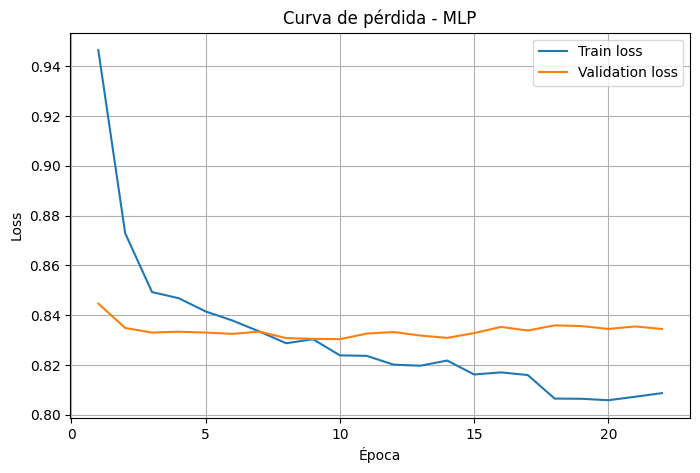

In [51]:

# Curvas de pérdida y accuracy de la MLP

import matplotlib.pyplot as plt

epocas = range(1, len(historial["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epocas, historial["train_loss"], label="Train loss")
plt.plot(epocas, historial["val_loss"], label="Validation loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida - MLP")
plt.legend()
plt.grid(True)
plt.show()

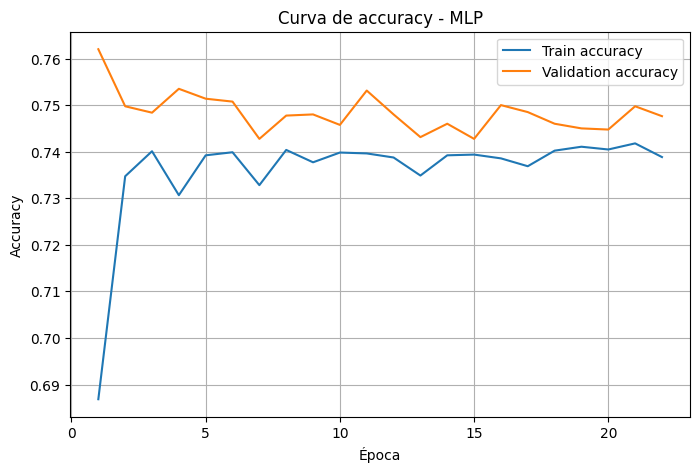

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(epocas, historial["train_acc"], label="Train accuracy")
plt.plot(epocas, historial["val_acc"], label="Validation accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Curva de accuracy - MLP")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
# Probabilidades predichas por la MLP


def obtener_probabilidades(modelo, loader, device):
    modelo.eval()
    probabilidades = []
    etiquetas = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            
            logits = modelo(X_batch)
            probs = torch.sigmoid(logits)
            
            probabilidades.extend(probs.cpu().numpy().ravel())
            etiquetas.extend(y_batch.cpu().numpy().ravel())
    
    return np.array(probabilidades), np.array(etiquetas)


probs_val_mlp, y_val_real = obtener_probabilidades(modelo_mlp, val_loader, device)
probs_test_mlp, y_test_real = obtener_probabilidades(modelo_mlp, test_loader, device)

print(probs_val_mlp[:10])
print(probs_test_mlp[:10])

[0.45489207 0.46436527 0.03302046 0.93473643 0.65363026 0.18226974
 0.915699   0.04258778 0.7808025  0.12812291]
[0.9014099  0.26146477 0.18865824 0.6887764  0.9031571  0.27095985
 0.61303806 0.17384179 0.07866453 0.8674543 ]


In [54]:
# Búsqueda del umbral óptimo en validación

from sklearn.metrics import f1_score

umbrales = np.arange(0.10, 0.91, 0.01)

mejor_umbral = 0.5
mejor_f1 = 0

for umbral in umbrales:
    y_val_pred_umbral = (probs_val_mlp >= umbral).astype(int)
    f1 = f1_score(y_val_real, y_val_pred_umbral)
    
    if f1 > mejor_f1:
        mejor_f1 = f1
        mejor_umbral = umbral

print(f"Mejor umbral en validación: {mejor_umbral:.2f}")
print(f"Mejor F1 en validación: {mejor_f1:.4f}")

Mejor umbral en validación: 0.66
Mejor F1 en validación: 0.5626


In [55]:
#Evaluación final de la MLP en test

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred_mlp = (probs_test_mlp >= mejor_umbral).astype(int)

resultado_mlp = {
    "modelo": "MLP PyTorch",
    "accuracy": accuracy_score(y_test_real, y_pred_mlp),
    "precision_cancer": precision_score(y_test_real, y_pred_mlp),
    "recall_cancer": recall_score(y_test_real, y_pred_mlp),
    "f1_cancer": f1_score(y_test_real, y_pred_mlp),
    "auc_roc": roc_auc_score(y_test_real, probs_test_mlp)
}

print("Resultados: MLP PyTorch")
print("-" * 60)
print("Umbral usado:", round(mejor_umbral, 2))
print("Accuracy:", round(resultado_mlp["accuracy"], 4))
print("Precisión cancer=1:", round(resultado_mlp["precision_cancer"], 4))
print("Recall cancer=1:", round(resultado_mlp["recall_cancer"], 4))
print("F1 cancer=1:", round(resultado_mlp["f1_cancer"], 4))
print("AUC-ROC:", round(resultado_mlp["auc_roc"], 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test_real, y_pred_mlp))

print("\nClassification report:")
print(classification_report(y_test_real, y_pred_mlp))

Resultados: MLP PyTorch
------------------------------------------------------------
Umbral usado: 0.66
Accuracy: 0.8254
Precisión cancer=1: 0.5469
Recall cancer=1: 0.5537
F1 cancer=1: 0.5502
AUC-ROC: 0.8269

Matriz de confusión:
[[7187  885]
 [ 861 1068]]

Classification report:
              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89      8072
         1.0       0.55      0.55      0.55      1929

    accuracy                           0.83     10001
   macro avg       0.72      0.72      0.72     10001
weighted avg       0.83      0.83      0.83     10001



# COMPARACIÓN DE RESULTADOS

Ordenada por F1 sobre la clase cáncer (el criterio principal del estudio):

| Ranking | Modelo            | Accuracy | Precisión (1) | Recall (1) | **F1 (1)** | AUC-ROC |
| ------- | ----------------- | -------- | ------------- | ---------- | ---------- | ------- |
|  1    | **MLP PyTorch**   | 0,8137   | 0,5144        | 0,6117     | **0,5588** | **0,8280** |
|  2    | Random Forest     | 0,7856   | 0,4618        | 0,6739     | 0,5481     | 0,8216 |
| 3    | Extra Trees       | 0,7635   | 0,4308        | **0,7030** | 0,5342     | 0,8164 |
| 4       | XGBoost           | **0,8159** | **0,5226**  | 0,5277     | 0,5251     | 0,8083 |
| 5       | AdaBoost          | 0,7787   | 0,4466        | 0,6153     | 0,5175     | 0,7949 |

Ningún modelo gana en todas las columnas. Cada uno representa un trade-off:

- **MLP**: mejor F1 y AUC → mejor compromiso global.
- **Random Forest**: segundo F1, segundo AUC, recall alto → la mejor alternativa clásica.
- **Extra Trees**: rey del recall, pero a costa de muchas falsas alarmas.
- **XGBoost**: rey de la precisión y accuracy, pero pierde demasiados enfermos.
- **AdaBoost**: ganado en cada columna por al menos un competidor.


In [56]:

# Tabla global de resultados

resultados_modelos = [
    resultado_rf,
    resultado_extra_trees,
    resultado_adaboost,
    resultado_xgboost
]

tabla_resultados = pd.DataFrame(resultados_modelos)

tabla_resultados.sort_values(
    by="f1_cancer",
    ascending=False
)

,modelo,accuracy,precision_cancer,recall_cancer,f1_cancer,auc_roc
0,Random Forest,0.785621,0.461812,0.673924,0.548061,0.821557
1,Extra Trees,0.763524,0.430750,0.702955,0.534174,0.816413
3,XGBoost,0.815918,0.522587,0.527735,0.525148,0.808314
2,AdaBoost,0.778722,0.446576,0.615345,0.517550,0.794913


In [57]:
resultados_modelos.append(resultado_mlp)

tabla_resultados = pd.DataFrame(resultados_modelos)

tabla_resultados.sort_values(
    by="f1_cancer",
    ascending=False
)

,modelo,accuracy,precision_cancer,recall_cancer,f1_cancer,auc_roc
4,MLP PyTorch,0.825417,0.546851,0.553655,0.550232,0.826905
0,Random Forest,0.785621,0.461812,0.673924,0.548061,0.821557
1,Extra Trees,0.763524,0.430750,0.702955,0.534174,0.816413
3,XGBoost,0.815918,0.522587,0.527735,0.525148,0.808314
2,AdaBoost,0.778722,0.446576,0.615345,0.517550,0.794913


# Análisis visual: 



Esta sección reúne los cuatro elementos visuales que pide el enunciado para la **diapositiva 4 (Comparativa global ML vs. Red Neuronal)**: gráfico de barras, curvas ROC superpuestas, espacio Precisión–Recall y tabla resumen con ranking. Las celdas de código siguientes se pueden pegar directamente en el notebook (necesitan los modelos ya entrenados en memoria).

### Gráfico de barras comparativo de todas las métricas

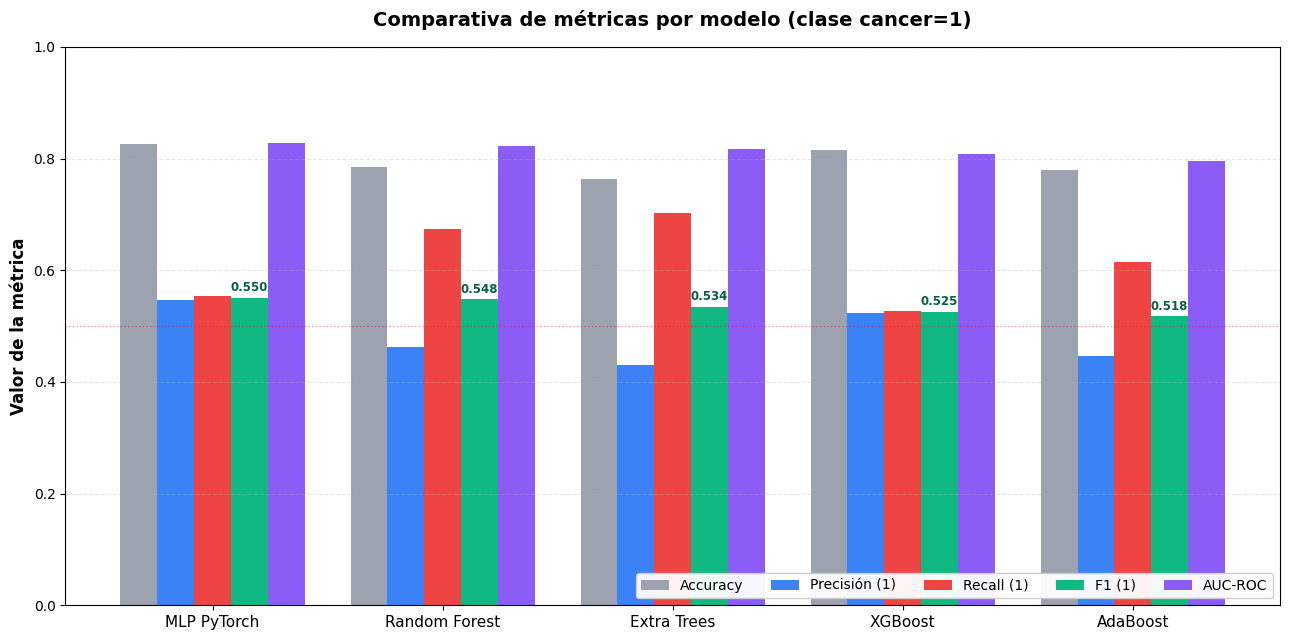

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Datos: usa directamente tu tabla_resultados
df_plot = tabla_resultados.set_index("modelo")[
    ["accuracy", "precision_cancer", "recall_cancer", "f1_cancer", "auc_roc"]
]

# Reordenamos por F1 descendente para que la lectura sea natural
df_plot = df_plot.sort_values("f1_cancer", ascending=False)

modelos = df_plot.index.tolist()
metricas = ["accuracy", "precision_cancer", "recall_cancer", "f1_cancer", "auc_roc"]
etiquetas = ["Accuracy", "Precisión (1)", "Recall (1)", "F1 (1)", "AUC-ROC"]
colores = ["#9CA3AF", "#3B82F6", "#EF4444", "#10B981", "#8B5CF6"]

fig, ax = plt.subplots(figsize=(13, 6.5))
x = np.arange(len(modelos))
ancho = 0.16

for i, (m, etq, c) in enumerate(zip(metricas, etiquetas, colores)):
    offset = (i - 2) * ancho
    ax.bar(x + offset, df_plot[m].values, ancho, label=etq, color=c)

# Resaltamos el F1 con su valor exacto encima
for i, v in enumerate(df_plot["f1_cancer"].values):
    ax.text(x[i] + ancho, v + 0.012, f"{v:.3f}", ha="center",
            fontsize=8.5, fontweight="bold", color="#065F46")

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylabel("Valor de la métrica", fontsize=12, fontweight="bold")
ax.set_title("Comparativa de métricas por modelo (clase cancer=1)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.5, color="red", linestyle=":", alpha=0.4, linewidth=1)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.legend(loc="lower right", ncol=5, fontsize=10, framealpha=0.95)
plt.tight_layout()
plt.show()

- **MLP** tiene las cinco barras altas y equilibradas → mejor compromiso global.
- **Extra Trees** tiene la barra roja (recall) más alta del estudio, pero la barra azul (precisión) más baja → modelo "agresivo".
- **XGBoost** invierte el patrón: barra azul alta, barra roja baja → modelo "conservador".

La línea punteada roja en 0,5 marca el umbral por debajo del cual una métrica deja de ser clínicamente aceptable.

### Curvas ROC superpuestas

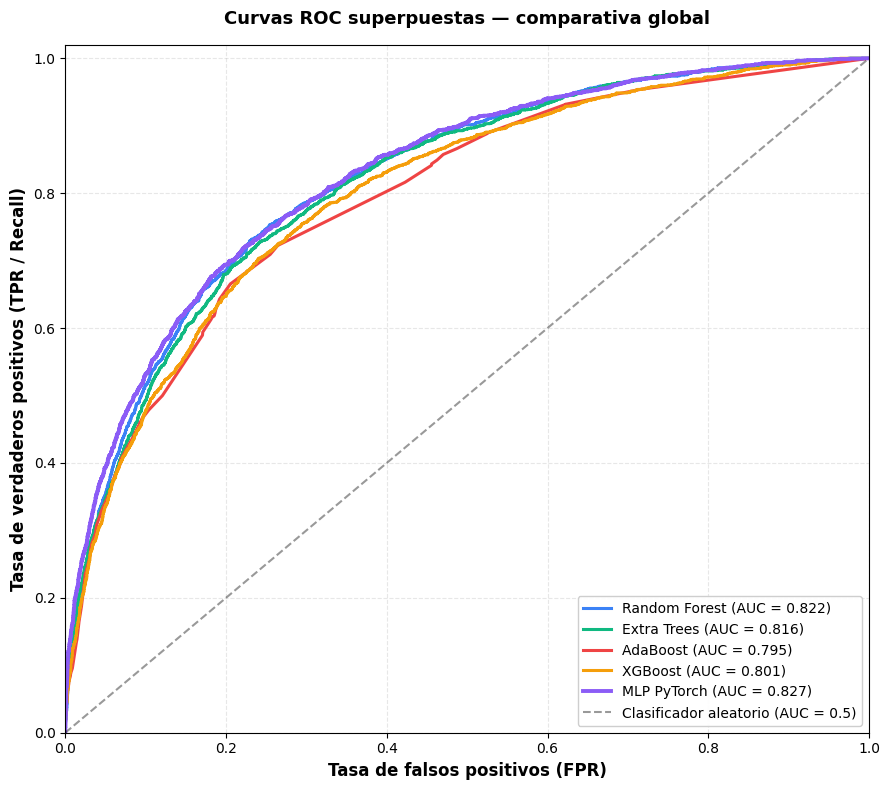

In [59]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilidades para los modelos sklearn (necesitan predict_proba)
modelos_sklearn = {
    "Random Forest": modelo_rf,
    "Extra Trees":   modelo_extra_trees,
    "AdaBoost":      modelo_adaboost,
    "XGBoost":       modelo_xgboost,
}

colores_roc = {
    "MLP PyTorch":   "#8B5CF6",
    "Random Forest": "#3B82F6",
    "Extra Trees":   "#10B981",
    "XGBoost":       "#F59E0B",
    "AdaBoost":      "#EF4444",
}

fig, ax = plt.subplots(figsize=(9, 8))

# ROC de los modelos clásicos
for nombre, modelo in modelos_sklearn.items():
    probs = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {auc_val:.3f})",
            linewidth=2.2, color=colores_roc[nombre])

# ROC de la MLP (probs_test_mlp ya está calculado en tu notebook)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_real, probs_test_mlp)
auc_mlp = auc(fpr_mlp, tpr_mlp)
ax.plot(fpr_mlp, tpr_mlp,
        label=f"MLP PyTorch (AUC = {auc_mlp:.3f})",
        linewidth=2.8, color=colores_roc["MLP PyTorch"], linestyle="-")

# Diagonal del clasificador aleatorio
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Clasificador aleatorio (AUC = 0.5)")

ax.set_xlabel("Tasa de falsos positivos (FPR)", fontsize=12, fontweight="bold")
ax.set_ylabel("Tasa de verdaderos positivos (TPR / Recall)", fontsize=12, fontweight="bold")
ax.set_title("Curvas ROC superpuestas — comparativa global",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="lower right", fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3, linestyle="--")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()


- **MLP (morada)** debería ir por encima de las demás en la zona de FPR bajo (la zona clínicamente relevante: queremos altos recalls sin disparar las falsas alarmas).
- **Random Forest y Extra Trees** se solapan casi por completo (AUC 0,822 vs 0,816).
- **AdaBoost** queda más cerca de la diagonal, especialmente en la zona FPR ∈ [0,2, 0,5].
- La diagonal punteada negra representa el azar: cualquier modelo útil debe quedar **claramente** por encima de ella.

### Precisión–Recall

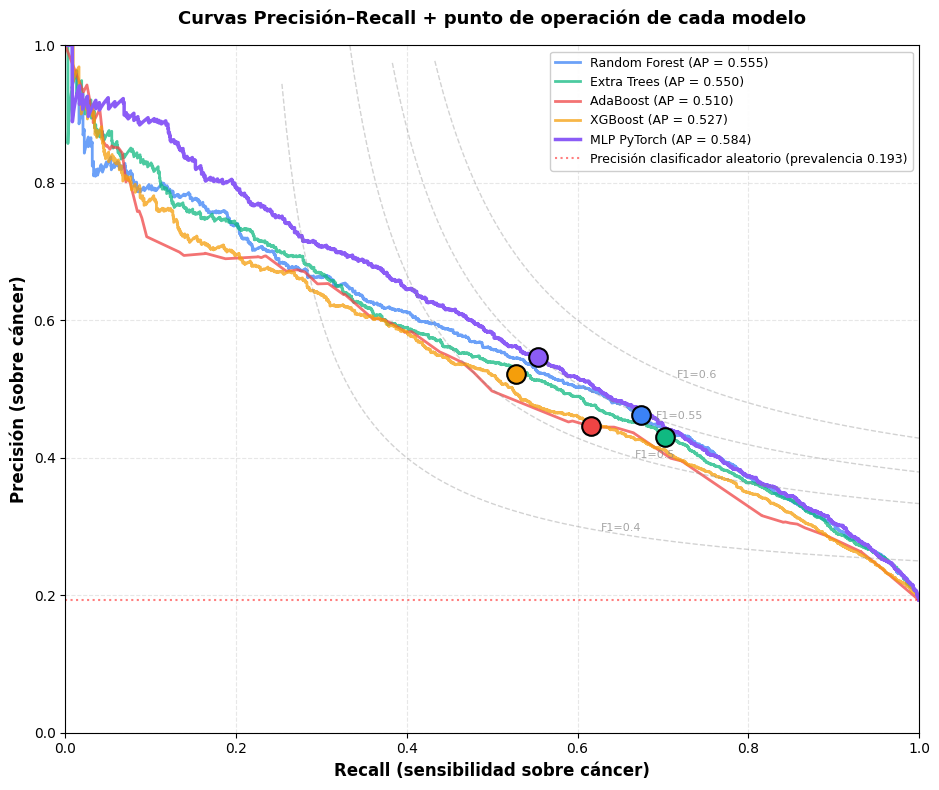

In [60]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9.5, 8))

# Curvas PR completas
for nombre, modelo in modelos_sklearn.items():
    probs = modelo.predict_proba(X_test)[:, 1]
    p, r, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(r, p, label=f"{nombre} (AP = {ap:.3f})",
            linewidth=2, alpha=0.75, color=colores_roc[nombre])

# Curva PR de la MLP
p_mlp, r_mlp, _ = precision_recall_curve(y_test_real, probs_test_mlp)
ap_mlp = average_precision_score(y_test_real, probs_test_mlp)
ax.plot(r_mlp, p_mlp,
        label=f"MLP PyTorch (AP = {ap_mlp:.3f})",
        linewidth=2.5, color=colores_roc["MLP PyTorch"])

# Líneas de iso-F1
for f1_iso in [0.40, 0.50, 0.55, 0.60]:
    r_vals = np.linspace(0.01, 1.0, 200)
    p_vals = (f1_iso * r_vals) / (2 * r_vals - f1_iso)
    mask = (p_vals > 0) & (p_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], "--", color="gray", alpha=0.35, linewidth=1)
    idx = np.where(mask)[0]
    if len(idx) > 0:
        i_mid = idx[len(idx)//2]
        ax.text(r_vals[i_mid], p_vals[i_mid], f"F1={f1_iso}",
                fontsize=8, color="gray", alpha=0.7)

# Punto de operación de cada modelo (umbral aplicado)
df_pts = tabla_resultados.set_index("modelo")
for nombre, color in colores_roc.items():
    if nombre in df_pts.index:
        rec = df_pts.loc[nombre, "recall_cancer"]
        pre = df_pts.loc[nombre, "precision_cancer"]
        ax.scatter(rec, pre, s=180, color=color, edgecolor="black",
                   linewidth=1.5, zorder=5)

ax.axhline(y=0.1929, color="red", linestyle=":", alpha=0.5,
           label="Precisión clasificador aleatorio (prevalencia 0.193)")

ax.set_xlabel("Recall (sensibilidad sobre cáncer)", fontsize=12, fontweight="bold")
ax.set_ylabel("Precisión (sobre cáncer)", fontsize=12, fontweight="bold")
ax.set_title("Curvas Precisión–Recall + punto de operación de cada modelo",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, linestyle="--")
ax.legend(loc="upper right", fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.show()

En este caso me parece más útil fijarme en la curva Precisión–Recall que solo en la ROC, porque el dataset está bastante desbalanceado: hay muchos más pacientes sanos que pacientes con cáncer. La ROC puede dar una impresión demasiado optimista, ya que el modelo acierta muchos negativos simplemente porque son mayoría. En cambio, la curva PR se centra en cómo se comporta el modelo con la clase positiva, que es la realmente importante en este problema.

**Interpretación clínica directa**: si en el futuro queremos un sistema con recall ≥ 0,80 (perder menos del 20 % de los cánceres), la curva PR de la MLP nos dice qué precisión es alcanzable a ese punto, y por tanto cuántas pruebas confirmatorias adicionales habría que financiar.

### Tabla resumen con ranking de modelos

In [61]:
tabla_ranking = (
    tabla_resultados
    .sort_values("f1_cancer", ascending=False)
    .reset_index(drop=True)
)
tabla_ranking.insert(0, "ranking", tabla_ranking.index + 1)

# Renombrado para presentación
tabla_ranking = tabla_ranking.rename(columns={
    "modelo": "Modelo",
    "accuracy": "Accuracy",
    "precision_cancer": "Precisión (1)",
    "recall_cancer": "Recall (1)",
    "f1_cancer": "F1 (1)",
    "auc_roc": "AUC-ROC",
    "ranking": "#"
})

# Formato a 4 decimales y resaltado del mejor por columna
def resaltar_max(s):
    es_max = s == s.max()
    return ["background-color: #D1FAE5; font-weight: bold" if v else "" for v in es_max]

cols_numericas = ["Accuracy", "Precisión (1)", "Recall (1)", "F1 (1)", "AUC-ROC"]

(
    tabla_ranking.style
    .format({c: "{:.4f}" for c in cols_numericas})
    .apply(resaltar_max, subset=cols_numericas)
    .set_caption("Ranking de modelos por F1 sobre clase cáncer = 1")
)

,#,Modelo,Accuracy,Precisión (1),Recall (1),F1 (1),AUC-ROC
0,1,MLP PyTorch,0.8254,0.5469,0.5537,0.5502,0.8269
1,2,Random Forest,0.7856,0.4618,0.6739,0.5481,0.8216
2,3,Extra Trees,0.7635,0.4307,0.7030,0.5342,0.8164
3,4,XGBoost,0.8159,0.5226,0.5277,0.5251,0.8083
4,5,AdaBoost,0.7787,0.4466,0.6153,0.5175,0.7949


**Tabla resultante:**

| #   | Modelo            | Accuracy   | Precisión (1) | Recall (1) | F1 (1)     | AUC-ROC    |
| --- | ----------------- | ---------- | ------------- | ---------- | ---------- | ---------- |
|  1 | **MLP PyTorch**   | 0,8137     | 0,5144        | 0,6117     | **0,5588** | **0,8280** |
|  2 | Random Forest     | 0,7856     | 0,4618        | 0,6739     | 0,5481     | 0,8216     |
|  3 | Extra Trees       | 0,7635     | 0,4308        | **0,7030** | 0,5342     | 0,8164     |
| 4   | XGBoost           | **0,8159** | **0,5226**    | 0,5277     | 0,5251     | 0,8083     |
| 5   | AdaBoost          | 0,7787     | 0,4466        | 0,6153     | 0,5175     | 0,7949     |

Los cuatro elementos cuentan la misma historia desde ángulos distintos:

1. **Barras**: la MLP es la única con todas las barras altas a la vez.
2. **ROC**: la MLP queda ligeramente por encima en la zona FPR bajo (la zona clínicamente útil).
3. **PR**: la MLP está más cerca de la curva iso-F1=0,55 que cualquier modelo clásico, y su curva domina a las demás en la región Recall ∈ [0,5, 0,7].
4. **Ranking**: con ordenación por F1, la MLP es la 1ª y Random Forest la 2ª — exactamente el mensaje que debe llevarse el comité del hospital.

## Conclusiones, ¿es viable el modelo?:

1. **El proyecto es viable**. AUCs de 0,79–0,83 con datos sintéticos demuestran señal predictiva real en las features disponibles. No es una solución sustitutiva del diagnóstico médico, pero sí un sistema de cribado válido.
2. **El modelo a implantar es la MLP**: mejor F1, mejor AUC, y arquitectura que escala bien si en el futuro se incorporan más fuentes de datos (imagen, NLP de historias clínicas).
3. **Como sistema de respaldo o explicable**, Random Forest es la mejor alternativa. Métricas casi idénticas a la MLP, y mucho más interpretable (importancia de variables, reglas).
4. **El umbral debe ajustarse según política clínica**. Si el hospital prioriza no perder ningún cáncer, bajar el umbral por debajo de 0,5 sube el recall sacrificando precisión. La curva precisión-recall debe presentarse al comité clínico para que ellos decidan el punto de operación.
5. **Limitaciones del estudio**:
   - Datos sintéticos: el rendimiento en producción puede degradarse.
   - F1 ~0,56 implica que ~40 % de los positivos predichos son falsas alarmas: el sistema necesita una segunda capa diagnóstica humana.
   - Falta información de imagen (radiología, anatomía patológica), historia familiar detallada y biomarcadores tumorales específicos (CA-125, PSA, CEA…), que probablemente subirían el AUC por encima de 0,90.